### **EDA - Eficiência Acadêmica**

In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar o DataFrame tratado para análise exploratória
df_eda = pd.read_parquet('../data/processed/microdados_eficiencia_academica_tratados.parquet')

In [15]:
df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   carga_horaria           60 non-null     int64  
 1   codigo_ciclo_matricula  60 non-null     str    
 2   fator_esforco_curso     60 non-null     float64
 3   nome_curso              60 non-null     str    
 4   tipo_curso              60 non-null     str    
 5   unidade_ensino          60 non-null     str    
dtypes: float64(1), int64(1), str(4)
memory usage: 6.2 KB


In [3]:
df_eda.head(10)

,carga_horaria,codigo_ciclo_matricula,fator_esforco_curso,nome_curso,tipo_curso,unidade_ensino
0,3630,2146517,1.108,Engenharia Elétrica,Bacharelado,Campus Paulo Afonso
1,3630,2168415,1.108,Engenharia Elétrica,Bacharelado,Campus Paulo Afonso
2,3990,2171089,1.078,Engenharia Mecânica,Bacharelado,Campus Simões Filho
3,3020,2187094,1.000,Computação,Licenciatura,Campus Santo Amaro
4,4140,2457272,1.025,Engenharia Ambiental,Bacharelado,Campus Vitória da Conquista
5,3890,2457273,1.108,Engenharia Elétrica,Bacharelado,Campus Vitória da Conquista
6,3720,2447665,1.108,Engenharia Elétrica,Bacharelado,Campus Salvador
7,3720,2447667,1.078,Engenharia Mecânica,Bacharelado,Campus Salvador
8,3720,2447671,1.111,Engenharia Química,Bacharelado,Campus Salvador
9,3290,2485508,1.000,Matemática,Licenciatura,Campus Valença Tento


In [4]:
# Medidas estatísticas dos atributos numéricos
df_eda.describe()

,carga_horaria,fator_esforco_curso
count,60.000000,60.000000
mean,3231.666667,1.044583
std,554.275880,0.046496
min,2010.000000,1.000000
25%,2950.000000,1.000000
50%,3275.000000,1.030000
75%,3720.000000,1.085000
max,4140.000000,1.175000


In [5]:
df_numerico = df_eda.select_dtypes(include='number')

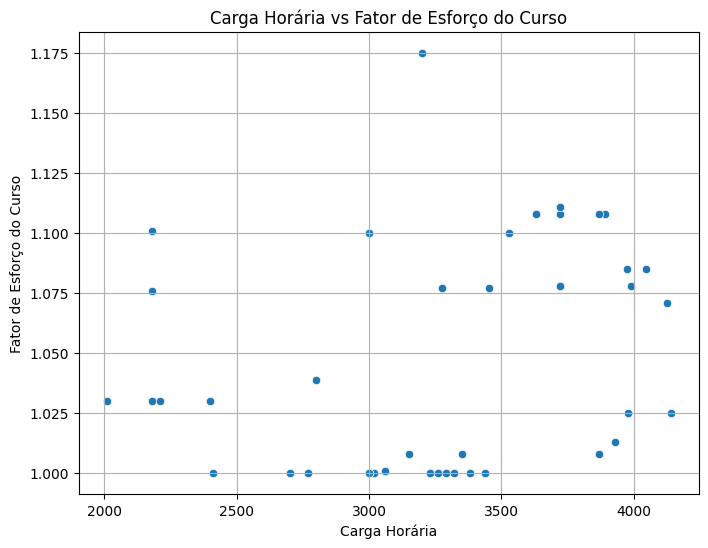

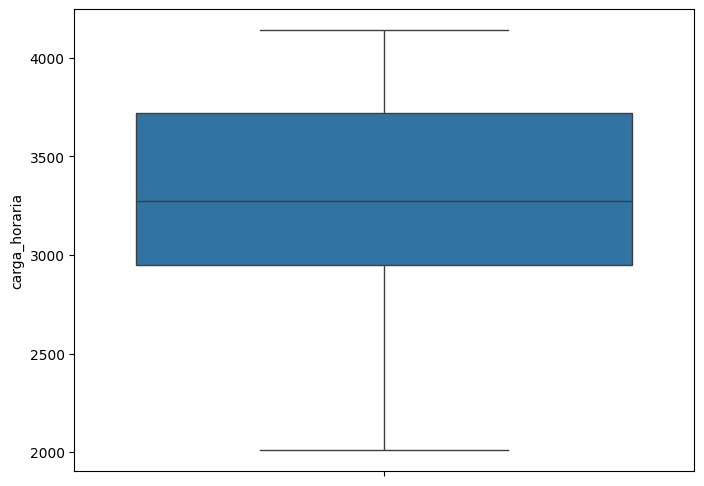

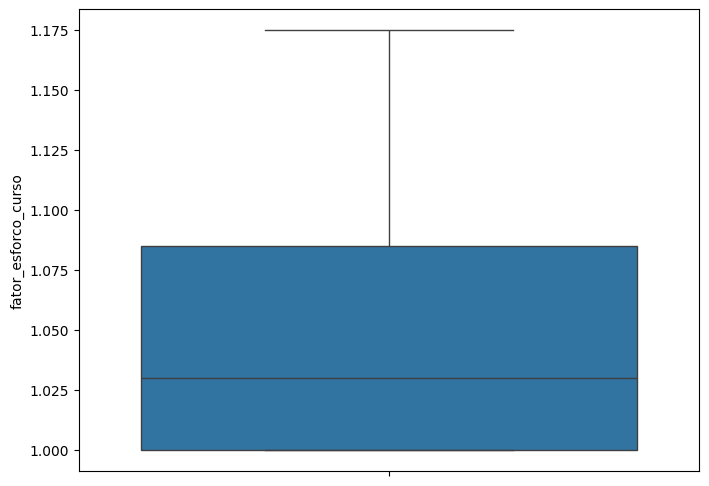

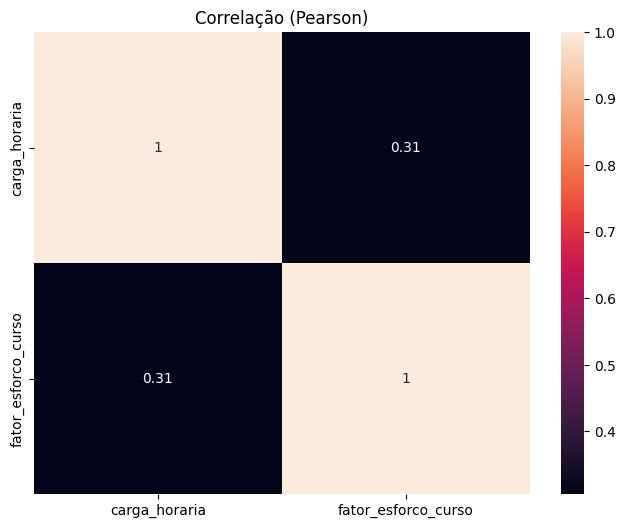

In [6]:
# Gráfico de dispersão
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_eda, x='carga_horaria', y='fator_esforco_curso')
plt.title('Carga Horária vs Fator de Esforço do Curso')
plt.xlabel('Carga Horária')
plt.ylabel('Fator de Esforço do Curso')
plt.grid(True)
plt.show()

# Boxplots
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_eda, y='carga_horaria')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_eda, y='fator_esforco_curso')
plt.show()

# Correlações
plt.figure(figsize=(8, 6))
sns.heatmap(df_numerico.corr(method='pearson'), annot=True)
plt.title('Correlação (Pearson)')
plt.show()

**Discussão**

Fator Esforço e Carga Horária apresentam relação não linear e fraca correlação.

**Merge com a base de matrículas**

In [ ]:
df_matriculas = pd.read_parquet('../data/processed/microdados_matriculas_tratados.parquet')

In [8]:
taxa_evasao = df_matriculas.groupby('codigo_ciclo_matricula').apply(
    lambda g: (g['categoria_situacao'] == 'Evadidos').sum() / len(g)
).reset_index(name='taxa_evasao_perc')

df_merge = df_eda.merge(taxa_evasao, on='codigo_ciclo_matricula', how='left')

# Remover ciclo órfão (sem par em matrículas) e outliers de tamanho de turma (n=1 e n=260)
df_merge = df_merge.dropna(subset=['taxa_evasao_perc'])
df_merge = df_merge[~df_merge['codigo_ciclo_matricula'].isin(['2187094', '2642476'])]

print(f"Ciclos na análise: {len(df_merge)}")


Ciclos na análise: 57


In [9]:
df_merge.info()

<class 'pandas.DataFrame'>
Index: 57 entries, 0 to 59
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   carga_horaria           57 non-null     int64  
 1   codigo_ciclo_matricula  57 non-null     str    
 2   fator_esforco_curso     57 non-null     float64
 3   nome_curso              57 non-null     str    
 4   tipo_curso              57 non-null     str    
 5   unidade_ensino          57 non-null     str    
 6   taxa_evasao_perc        57 non-null     float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.7 KB


In [10]:
df_num = df_merge.select_dtypes(include='number')

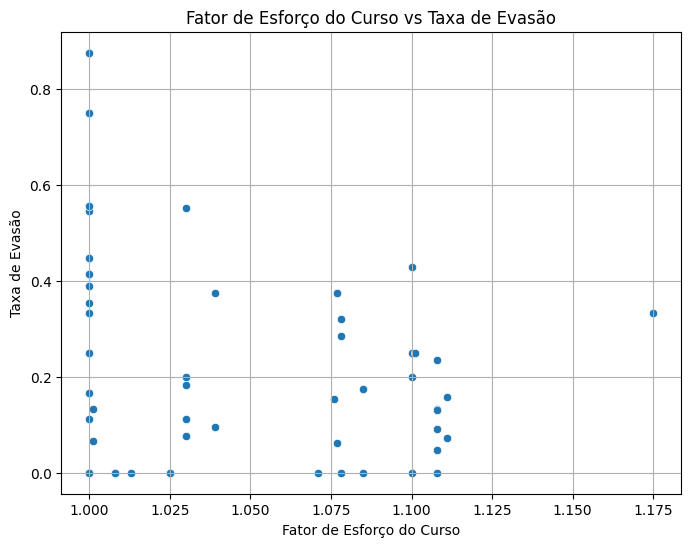

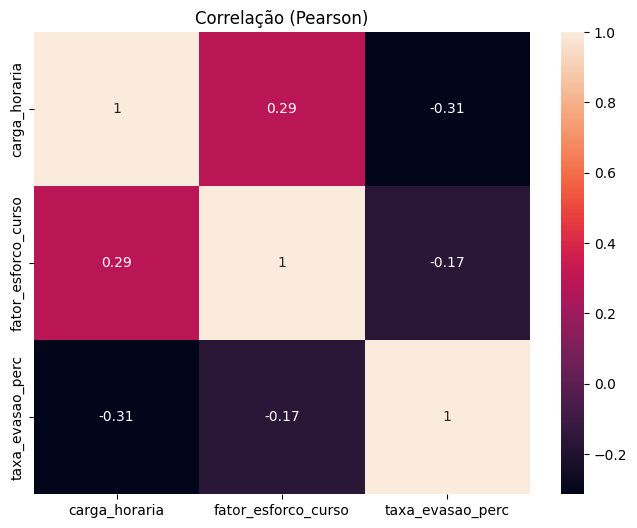

In [11]:
# Gráfico de dispersão
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_merge, x='fator_esforco_curso', y='taxa_evasao_perc')
plt.title('Fator de Esforço do Curso vs Taxa de Evasão')
plt.xlabel('Fator de Esforço do Curso')
plt.ylabel('Taxa de Evasão')
plt.grid(True)
plt.show()

# Correlações
plt.figure(figsize=(8, 6))
sns.heatmap(df_num.corr(method='pearson'), annot=True)
plt.title('Correlação (Pearson)')
plt.show()

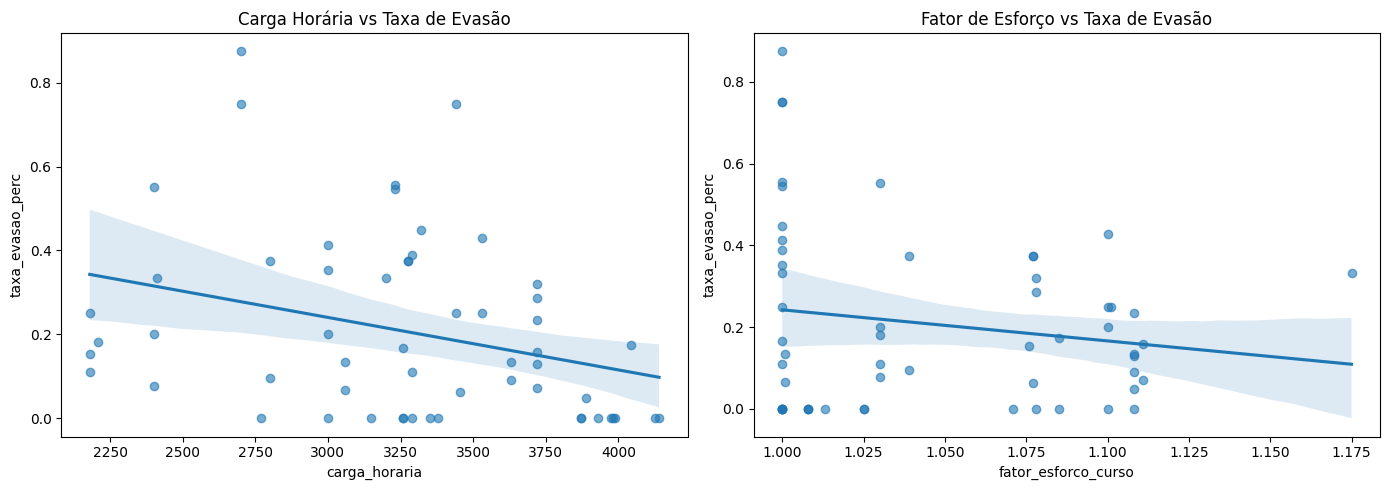

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df_merge, x='carga_horaria', y='taxa_evasao_perc', ax=axes[0], scatter_kws={'alpha': 0.6})
axes[0].set_title('Carga Horária vs Taxa de Evasão')

sns.regplot(data=df_merge, x='fator_esforco_curso', y='taxa_evasao_perc', ax=axes[1], scatter_kws={'alpha': 0.6})
axes[1].set_title('Fator de Esforço vs Taxa de Evasão')
plt.tight_layout()


C:\Users\anabz\AppData\Local\Temp\ipykernel_1612\1330828178.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=evasao_por_carga, x='carga_horaria', y='taxa_evasao_perc', palette='viridis')


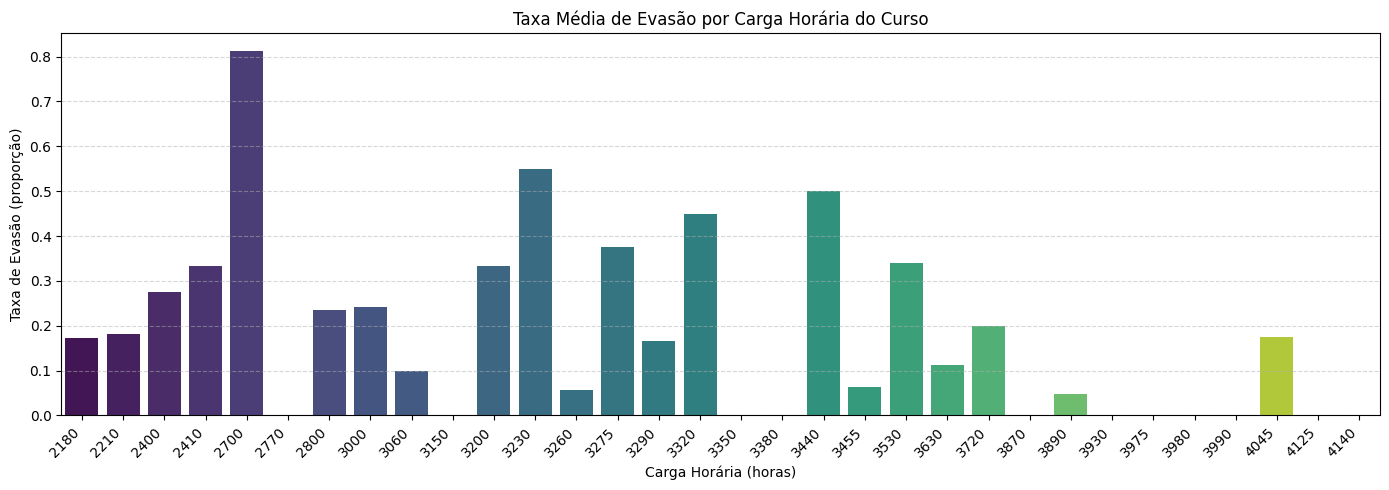

In [13]:

# Média de taxa de evasão por valor único de carga horária, ordenado crescentemente
evasao_por_carga = (
    df_merge.groupby('carga_horaria')['taxa_evasao_perc']
    .mean()
    .reset_index()
    .sort_values('carga_horaria')
)

plt.figure(figsize=(14, 5))
sns.barplot(data=evasao_por_carga, x='carga_horaria', y='taxa_evasao_perc', palette='viridis')
plt.title('Taxa Média de Evasão por Carga Horária do Curso')
plt.xlabel('Carga Horária (horas)')
plt.ylabel('Taxa de Evasão (proporção)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [14]:
df_num.corr(method='spearman')

,carga_horaria,fator_esforco_curso,taxa_evasao_perc
carga_horaria,1.000000,0.338494,-0.372954
fator_esforco_curso,0.338494,1.000000,-0.129388
taxa_evasao_perc,-0.372954,-0.129388,1.000000
